In [12]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive") # change path here!

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [14]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [15]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [16]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Fare'] = titanic_df['Fare'].fillna(titanic_df['Fare'].median())

most_frequent_port = titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(most_frequent_port)

titanic_df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


Age i Fare uzupełniłem medianami, aby wartości skrajne nie zaburzały wyników. Pojedyncze braki w Embarked zastąpiłem najczęściej występującą wartością.

In [17]:
titanic_df['Deck'] = titanic_df['Cabin'].str[0]
titanic_df['Deck'] = titanic_df['Deck'].fillna('U')
titanic_df = titanic_df.drop('Cabin', axis=1)

print(titanic_df['Deck'].value_counts())

Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


Zrezygnowałem z całkowitego usuwania Cabin. Teraz wyciągam informacje o Deck, a braki uzupełniam U (Unknown).

In [18]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True)
titanic_df = titanic_df.drop(['Name', 'Ticket'], axis=1)
titanic_df = pd.get_dummies(titanic_df, columns=['Deck'], drop_first=True, dtype=int)

titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
PassengerId,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,False,True,0,0,0,0,0,0,0,1
2,1,1,1,38.0,1,0,71.2833,False,False,0,1,0,0,0,0,0,0
3,1,3,1,26.0,0,0,7.9250,False,True,0,0,0,0,0,0,0,1
4,1,1,1,35.0,1,0,53.1000,False,True,0,1,0,0,0,0,0,0
5,0,3,0,35.0,0,0,8.0500,False,True,0,0,0,0,0,0,0,1


Aby przygotować zbiór do trenowania modeli ML, zakodowałem zmienne tekstowe. Płeć (Sex) została zmapowana na wartości binarne. Port zaokrętowania (Embarked) zakodowałem za pomocą metody One-Hot Encoding, tworząc niezależne flagi dla poszczególnych portów. Zbędne kolumny tekstowe (imię i nr biletu) zostały usunięte. Deck zakodowałem również przez One-Hot Encoding.

Wnioski z EDA:

*   Klasa pasażera i płeć mocno wpływały na przeżywalność (wyraźna przewaga uratowanych kobiet i osób z 1. klasy).
*   Stworzona zmienna FamilySize pokazała, że osoby podróżujące z bliskimi miały większą szansę przeżycia niż samotne.
*   Wizualizacje za pomocą wykresów pudełkowych ukazały asymetrię w kolumnie Fare. Część pasażerów zapłaciła za bilet ekstremalnie wysokie kwoty, co stanowi wyraźne wartości odstające w zbiorze.





In [19]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score

titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Wymiary zbioru treningowego (X_train): {X_train.shape}")
print(f"Wymiary zbioru testowego (X_test): {X_test.shape}")

Wymiary zbioru treningowego (X_train): (712, 17)
Wymiary zbioru testowego (X_test): (179, 17)


In [20]:
dummy_model = DummyClassifier(strategy='most_frequent')

dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
print(f"Dokładność DummyClassifier na zbiorze testowym: {dummy_accuracy:.2%}")

Dokładność DummyClassifier na zbiorze testowym: 58.66%


Najlepsze hiperparametry KNN: {'metric': 'manhattan', 'n_neighbors': 11}
Dokładność najlepszego KNN na zbiorze testowym: 80.45%


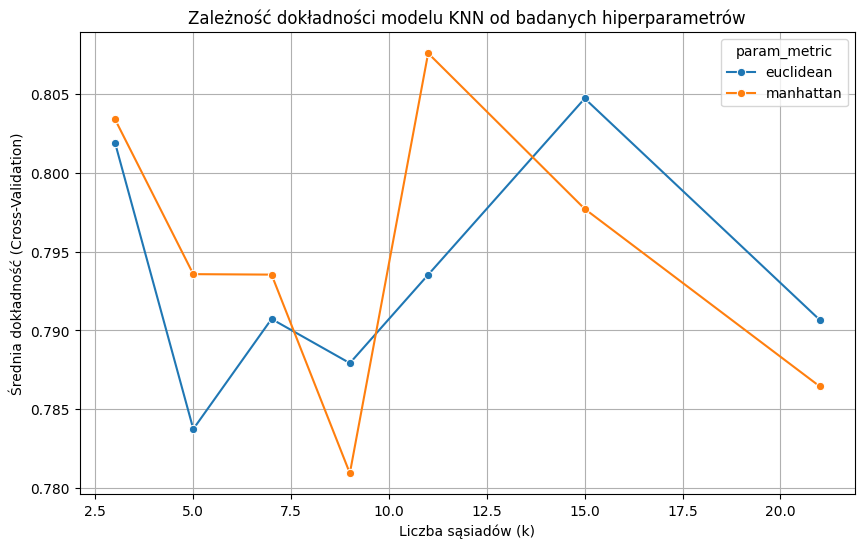

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# standaryzacja danych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# siatka z parametrami, które chcę zbadać
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'metric': ['euclidean', 'manhattan']
}

# Grid Search z 5-krotną kroswalidacją
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)

print(f"Najlepsze hiperparametry KNN: {grid_knn.best_params_}")
print(f"Dokładność najlepszego KNN na zbiorze testowym: {grid_knn.score(X_test_scaled, y_test):.2%}")

results_knn = pd.DataFrame(grid_knn.cv_results_)

plt.figure(figsize=(10, 6))
sns.lineplot(data=results_knn, x='param_n_neighbors', y='mean_test_score', hue='param_metric', marker='o')
plt.title('Zależność dokładności modelu KNN od badanych hiperparametrów')
plt.ylabel('Średnia dokładność (Cross-Validation)')
plt.xlabel('Liczba sąsiadów (k)')
plt.grid(True)
plt.show()

Najlepsze hiperparametry dla Drzewa Decyzyjnego: {'criterion': 'entropy', 'max_depth': 7}
Dokładność (Accuracy) Drzewa na zbiorze testowym: 79.33%


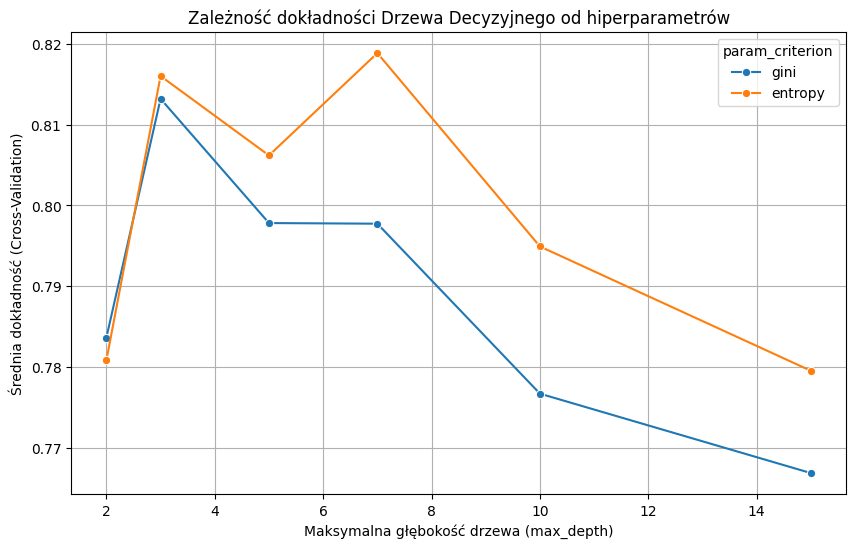

In [22]:
from sklearn.tree import DecisionTreeClassifier

# siatka parametrów dla Drzewa Decyzyjnego
param_grid_dt = {
    'max_depth': [2, 3, 5, 7, 10, 15],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

print(f"Najlepsze hiperparametry dla Drzewa Decyzyjnego: {grid_dt.best_params_}")
print(f"Dokładność (Accuracy) Drzewa na zbiorze testowym: {grid_dt.score(X_test, y_test):.2%}")

results_dt = pd.DataFrame(grid_dt.cv_results_)

plt.figure(figsize=(10, 6))
sns.lineplot(data=results_dt, x='param_max_depth', y='mean_test_score', hue='param_criterion', marker='o')
plt.title('Zależność dokładności Drzewa Decyzyjnego od hiperparametrów')
plt.ylabel('Średnia dokładność (Cross-Validation)')
plt.xlabel('Maksymalna głębokość drzewa (max_depth)')
plt.grid(True)
plt.show()

# Podsumowanie

1. **Ochrona przed wyciekiem danych (Data Leakage):** Przed etapem skalowania i trenowania, podzieliłem dane na zbiór treningowy i testowy (train_test_split). Standaryzację (StandardScaler) dopasowałem (fit) tylko na zbiorze treningowym, a na zbiorze testowym wykonałem jedynie transformację. Dzięki temu model na żadnym etapie nie miał dostępu do informacji ze zbioru testowego.

2. **Model referencyjny (Baseline):** Zastosowanie DummyClassifier ze strategią most_frequent dało dokładność na poziomie ok. 58.6%. Jest to logiczne, bo na Titanicu przeżyło około 38% pasażerów - stawiając zawsze na klasę "nie przeżył" (0), mamy rację w ~60% przypadków. Był to nasz próg odniesienia.

3. **Uzasadnienie wyboru metryk:** Główną metryką optymalizowaną podczas przeszukiwania siatki (GridSearchCV) było Accuracy (Dokładność), ponieważ zbiór danych Titanica nie jest ekstremalnie niezbalansowany (stosunek klas wynosi ok. 62% do 38%). Accuracy w czytelny sposób odpowiada na pytanie: "Jaką część wszystkich pasażerów model sklasyfikował poprawnie?". W pełnej ocenie klasyfikatorów wspierałem się koncepcyjnie również metrykami Precision (Precyzja) oraz Recall (Czułość), które można wyliczyć z tablicy pomyłek. W kontekście Titanica, oceniając klasę 1 (ocalałych), zależy nam na zbalansowanym podejściu (metryka F1-score). Chcemy, aby model nie wskazywał fałszywych ocalałych (wysoka Precyzja), ale jednocześnie potrafił wyłapać jak największą liczbę osób, które faktycznie przeżyły (wysoka Czułość). Accuracy dobrze się sprawdziło do wyłonienia najlepszych hiperparametrów, ponieważ oba modele przekroczyły próg 79%, poprawiając wyniki względem modelu bazowego (Dummy Classifier).

4. **Wyniki i analiza modelu K-Nearest Neighbors (KNN):**
W modelu KNN kluczowa była standaryzacja - bez niej zmienna Fare (opłata) o dużych wartościach zdominowałaby zmienną Pclass przy obliczaniu odległości.

*   Najlepsze parametry: metric: manhattan, n_neighbors: 11
*   Dokładność na teście: 80.45%
*   Wniosek z wykresu: Dokładność drastycznie spada przy zbyt małej liczbie sąsiadów (np. 3 lub 5), co oznacza dopasowywanie się do lokalnego szumu. Optymalne wygładzenie uzyskałem badając opinie 11 najbliższych sąsiadów.

5. **Wyniki i analiza modelu Drzewa Decyzyjnego (Decision Tree):**



*   Najlepsze parametry: criterion: entropy, max_depth: 7
*   Dokładność na teście: 79.33%
*   Wniosek z wykresu (Ochrona przed przetrenowaniem): Wykres obrazuje zjawisko overfittingu (przetrenowania). Gdy limit głębokości drzewa (max_depth) przekracza 7, celność na zbiorze walidacyjnym zaczyna gwałtownie spadać. Model staje się zbyt skomplikowany i uczy się wyjątków na pamięć. Ograniczenie głębokości to skuteczna metoda regularyzacji.













